VGG NET
Lab Record Program 3

In [21]:

from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.applications.vgg16 import VGG16
from keras.models import Sequential
from keras.layers import InputLayer, Dense, Dropout,GlobalAveragePooling2D
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [22]:
#Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [23]:
#To Correctly input the data into the model
print(x_train.shape)  
print(y_train.shape)  
print(x_test.shape)  
print(y_test.shape)  

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [24]:
#NOrmalize the images to the range [0, 1]
x_train =  x_train / 255.0
x_test = x_test / 255.0

In [25]:
#One-hot encode the labels(CIFAR-10 has 10 classes)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
#Load VGG16 model pre-trained on ImageNet , without the top paeyrs (fully connected layers)
#include_top=False → Load only the convolutional base (without the dense layers)
#You get the pre-trained feature extraction capability from ImageNet
base_model = VGG16(weights='imagenet', include_top=False)  

In [ ]:
#Freeze the layer of VGG16
# freezes the pre-trained weights of the convolutional layers, so they won't be updated during training
#Pre-trained VGG16 (frozen) → Your custom Dense layers (trainable)
#               ↓                              ↓
#        Feature Extractor            Adapt for CIFAR-10
#        (ImageNet knowledge)         (Train with CIFAR-10 data)
for layer in base_model.layers:
    layer.trainable = False

In [28]:
#Alternate method , Freeze early layers, fine tune last block
#for layer in base_model.layers[:-4]:
#    layer.trainable = False

In [29]:
#build the model
model = Sequential()

#Define the input shape
model.add(InputLayer(input_shape=(32, 32, 3)))  #Added this line for new image data

#Add THE vgg16 base model
model.add(base_model)

#Flatten . pool the output from VGG16s convolutional layers
#model.add(Flatten()) use when dataest is large an. Preserve spatial information
model.add(GlobalAveragePooling2D())  #Global Average Pooling to reduce dimensions

#Add a fully connected layer with 256 units and ReLU activation
model.add(Dense(256,activation='relu'))

#Add Dropout for regularization
model.add(Dropout(0.50))

#Add output layer with 10 units (for 10 classes ) and softmax activation
model.add(Dense(10,activation='softmax'))

#compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#print model summary
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 global_average_pooling2d_1  (None, 512)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 10)                2570      
                                                                 
Total params: 14848586 (56.64 MB)
Trainable params: 133898 (523.04 KB)
Non-trainable params: 14714688 (56.13 MB)
_______

In [30]:
#data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [31]:
#Fit the model using data augmentation
batch_size = 64
epochs = 3
train_generator = datagen.flow(x_train, y_train, batch_size=batch_size)

In [32]:
print(y_train.shape)

(50000, 10)


In [33]:
#train model
history = model.fit(train_generator, 
                    steps_per_epoch=x_train.shape[0] // batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test)
                   )

Epoch 1/3
781/781 [==============================] - 84s 107ms/step - loss: 1.9917 - accuracy: 0.2860 - val_loss: 1.6428 - val_accuracy: 0.4510
Epoch 2/3
781/781 [==============================] - 82s 106ms/step - loss: 1.6779 - accuracy: 0.4081 - val_loss: 1.5001 - val_accuracy: 0.4849
Epoch 3/3
781/781 [==============================] - 83s 107ms/step - loss: 1.5796 - accuracy: 0.4456 - val_loss: 1.4240 - val_accuracy: 0.5089


In [39]:
#Evaluate The Model
test_loss,test_acc = model.evaluate(x_test,y_test)
print(f'Test Accuracy:{test_acc}')

313/313 [==============================] - 18s 56ms/step - loss: 1.4240 - accuracy: 0.5089
Test Accuracy:0.508899986743927


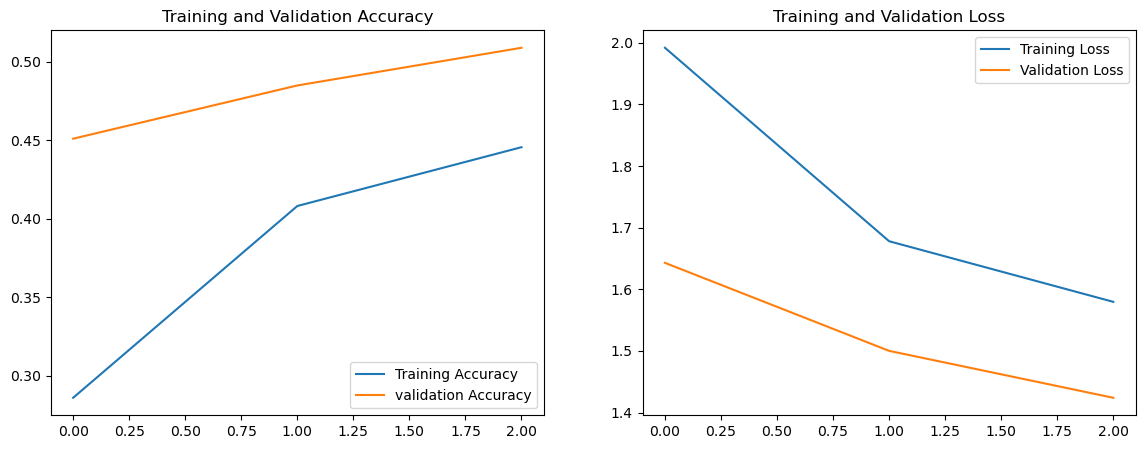

In [41]:
#plot Training and validation accuracy and loss
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validation Accuracy')
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./VGG16.png')
plt.show()
